In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# =========================
# Hyperparameters
# =========================
batch_size = 32
epochs = 5
learning_rate = 0.001

In [ ]:
# =========================
# Transform (FIXED: MNIST best size 28x28)
# =========================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [ ]:
# =========================
# Dataset
# =========================
full_train_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.17MB/s]


In [ ]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

In [ ]:
train_data, val_data = random_split(
    full_train_dataset,
    [train_size, val_size]
)

In [ ]:
train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
class EnhancedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Dropout(0.25),

            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
def run_experiment(model, name):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    print("\n" + "=" * 60)
    print(f"START TRAINING: {name}")
    print("=" * 60)

    for epoch in range(epochs):

        # ================= TRAINING =================
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_losses.append(total_loss / len(train_loader))
        train_accs.append(100 * correct / total)

        # ================= VALIDATION =================
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(100 * val_correct / val_total)

        print(
            f"Epoch [{epoch+1}/{epochs}] - {name} | "
            f"Train Loss: {train_losses[-1]:.4f} | "
            f"Train Acc: {train_accs[-1]:.2f}% | "
            f"Val Loss: {val_losses[-1]:.4f} | "
            f"Val Acc: {val_accs[-1]:.2f}%"
        )

    # ================= TEST =================
    model.eval()
    correct = 0
    total = 0

    test_preds = []
    test_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_acc = 100 * correct / total

    return train_losses, train_accs, val_losses, val_accs, test_acc

In [ ]:
model1 = SimpleCNN().to(device)
model2 = EnhancedCNN().to(device)

loss1, acc1, vloss1, vacc1, test1 = run_experiment(
    model1,
    "Simple CNN"
)

loss2, acc2, vloss2, vacc2, test2 = run_experiment(
    model2,
    "Enhanced CNN"
)


START TRAINING: Simple CNN
Epoch [1/5] - Simple CNN | Train Loss: 0.1490 | Train Acc: 95.44% | Val Loss: 0.0590 | Val Acc: 98.10%
Epoch [2/5] - Simple CNN | Train Loss: 0.0493 | Train Acc: 98.42% | Val Loss: 0.0489 | Val Acc: 98.43%
Epoch [3/5] - Simple CNN | Train Loss: 0.0342 | Train Acc: 98.86% | Val Loss: 0.0392 | Val Acc: 98.72%
Epoch [4/5] - Simple CNN | Train Loss: 0.0234 | Train Acc: 99.29% | Val Loss: 0.0347 | Val Acc: 98.94%
Epoch [5/5] - Simple CNN | Train Loss: 0.0209 | Train Acc: 99.29% | Val Loss: 0.0344 | Val Acc: 98.93%

START TRAINING: Enhanced CNN
Epoch [1/5] - Enhanced CNN | Train Loss: 0.2002 | Train Acc: 93.89% | Val Loss: 0.0612 | Val Acc: 97.99%
Epoch [2/5] - Enhanced CNN | Train Loss: 0.0978 | Train Acc: 97.06% | Val Loss: 0.0449 | Val Acc: 98.63%
Epoch [3/5] - Enhanced CNN | Train Loss: 0.0775 | Train Acc: 97.71% | Val Loss: 0.0418 | Val Acc: 98.71%
Epoch [4/5] - Enhanced CNN | Train Loss: 0.0647 | Train Acc: 98.03% | Val Loss: 0.0365 | Val Acc: 98.97%
Epoch [

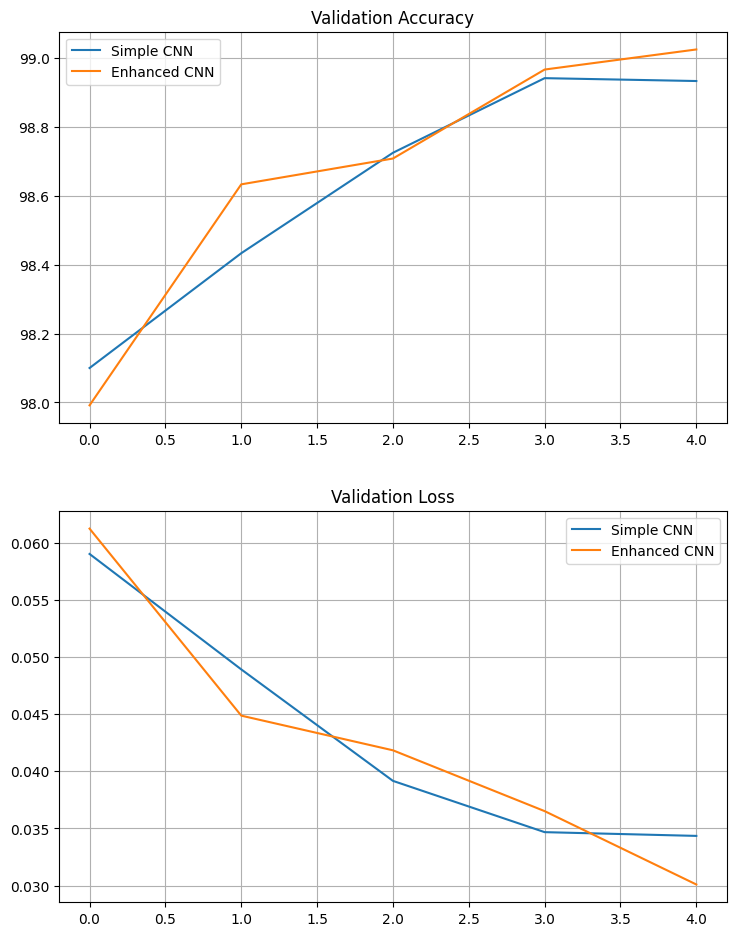

In [ ]:
plt.figure(figsize=(8, 10))

plt.subplot(2, 1, 1)
plt.plot(vacc1, label="Simple CNN")
plt.plot(vacc2, label="Enhanced CNN")
plt.title("Validation Accuracy")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(vloss1, label="Simple CNN")
plt.plot(vloss2, label="Enhanced CNN")
plt.title("Validation Loss")
plt.legend()
plt.grid()

plt.tight_layout(pad=3)
plt.show()

In [ ]:
print("\n================ FINAL RESULTS ================\n")
print(f"Simple CNN Accuracy   : {test1:.2f}%")
print(f"Enhanced CNN Accuracy : {test2:.2f}%")
print("===============================================")


================ FINAL RESULTS ================

Simple CNN Accuracy   : 99.03%
Enhanced CNN Accuracy : 99.06%
